In [1]:
# library for graph creation and manipulation
import networkx as nx
nx.__version__

'3.3'

In [2]:
# undirected graph
u_G = nx.Graph()
print(u_G)
print(u_G.is_directed())

# directed graph
d_G = nx.DiGraph()
d_G.name = "directed graph"  # graph level attribute
d_G.graph["age"] = 24  # another custom graph level attribute/ feature
print(d_G.is_directed())
print(d_G)
print(d_G.graph)  # print graph level properties/ features

Graph with 0 nodes and 0 edges
False
True
DiGraph named 'directed graph' with 0 nodes and 0 edges
{'name': 'directed graph', 'age': 24}


In [3]:
import numpy as np

# adding node to graph - node name, features (can be anything), optional label
u_G.add_node(0, feature=np.random.random((3, 3, 3)), label=0)
u_G.nodes(data=True)

# get node attributes
node0_feats = u_G.nodes[0]['feature']
node0_label = u_G.nodes[0]['label']
print(f"node 0 features -> {node0_feats}\n \
      node 0 label -> {node0_label}")

# add few more nodes
n_nodes = 5
for i in range(1, 6):
    u_G.add_node(i, feature=np.random.random((3, 3, 3)), label=i)

# print all node features iteratively
print(f"number of nodes -> {u_G.number_of_nodes()}")
for i in u_G.nodes(data=True):
    print(i)


node 0 features -> [[[0.99353936 0.44830459 0.9240641 ]
  [0.44607397 0.17688747 0.59842729]
  [0.50024382 0.80572154 0.92283749]]

 [[0.42268467 0.59353679 0.90113644]
  [0.62138874 0.91404032 0.57335329]
  [0.99366179 0.4675813  0.27334468]]

 [[0.1836456  0.07708792 0.24284256]
  [0.04502692 0.2364281  0.69132229]
  [0.9727497  0.31048949 0.45840718]]]
       node 0 label -> 0
number of nodes -> 6
(0, {'feature': array([[[0.99353936, 0.44830459, 0.9240641 ],
        [0.44607397, 0.17688747, 0.59842729],
        [0.50024382, 0.80572154, 0.92283749]],

       [[0.42268467, 0.59353679, 0.90113644],
        [0.62138874, 0.91404032, 0.57335329],
        [0.99366179, 0.4675813 , 0.27334468]],

       [[0.1836456 , 0.07708792, 0.24284256],
        [0.04502692, 0.2364281 , 0.69132229],
        [0.9727497 , 0.31048949, 0.45840718]]]), 'label': 0})
(1, {'feature': array([[[0.66825149, 0.28103709, 0.65837655],
        [0.87324637, 0.8240773 , 0.18386971],
        [0.97775286, 0.62927506, 0.687

(0, 3, {'weight': 0.5, 'exist': 1})
(0, 1, {'weight': 0.56})
(0, 0, {'weight': 1.0, 'exist': 1})
(0, 2, {'weight': 0.67, 'exist': 1})
(1, 5, {'weight': 0.3, 'exist': 1})
(1, 1, {'weight': 1.0, 'exist': 1})
(1, 4, {'weight': 1.0, 'exist': 1, 'distance': 0.11})
[(0, 3, {'weight': 0.5, 'exist': 1}), (0, 1, {'weight': 0.56}), (0, 0, {'weight': 1.0, 'exist': 1}), (0, 2, {'weight': 0.67, 'exist': 1}), (1, 5, {'weight': 0.3, 'exist': 1}), (1, 1, {'weight': 1.0, 'exist': 1}), (1, 4, {'weight': 1.0, 'exist': 1, 'distance': 0.11})]
[(0, 3), (0, 1), (0, 0), (0, 2), (1, 5), (1, 1), (1, 4)]
{0: {3: {'weight': 0.5, 'exist': 1}, 1: {'weight': 0.56}, 0: {'weight': 1.0, 'exist': 1}, 2: {'weight': 0.67, 'exist': 1}}, 1: {0: {'weight': 0.56}, 5: {'weight': 0.3, 'exist': 1}, 1: {'weight': 1.0, 'exist': 1}, 4: {'weight': 1.0, 'exist': 1, 'distance': 0.11}}, 2: {0: {'weight': 0.67, 'exist': 1}}, 3: {0: {'weight': 0.5, 'exist': 1}}, 4: {1: {'weight': 1.0, 'exist': 1, 'distance': 0.11}}, 5: {1: {'weight': 0.3

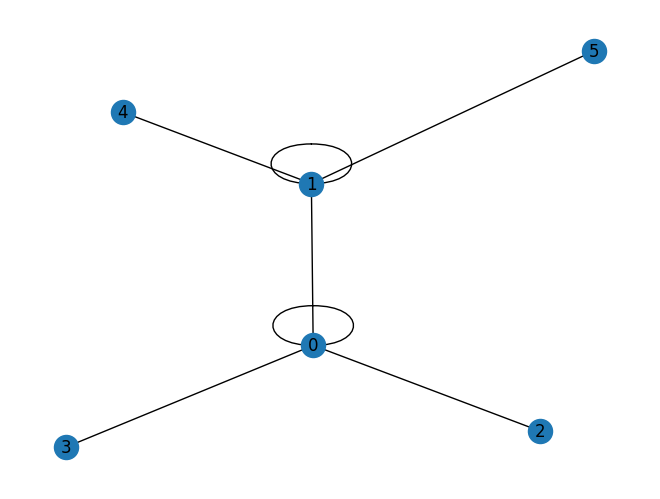

In [4]:
# once we have some nodes, create edges between them
# (source, dest., <features>)
u_G.add_edge(0, 3, weight=0.5, exist=1)  # here weight and exist are edge feature
u_G.edges(data=True)

# multiple edges can be added together as
u_G.add_edges_from([
    (1, 0, {"weight": 0.56}),  # not neccessary that all edges/ nodes have same features
    (0, 0, {"weight": 1.0, "exist": 1}),
    (5, 1, {"weight": 0.3, "exist": 1}),
    (1, 1, {"weight": 1.0, "exist": 1}),
    (1, 4, {"weight": 1.0, "exist": 1}),
    (0, 2, {"weight": 0.61, "exist": 1}),
    (2, 0, {"weight": 0.67, "exist": 1}),  # NOTE: this is an undirected graph => edge(0, 2) == edge(2, 0)
])

# edge features can also be assigned as 
u_G.edges[1, 4]['distance'] = 0.11  # u, v, <feats>

# loop over and print edges
for edge in u_G.edges(data=True):
    print(edge)
print(u_G.edges(data=True))

# NOTE: draw the graph with node labels
nx.draw(u_G, with_labels=True)

print(u_G.edges)
print(u_G.adj)

In [5]:
# degree of a name
nodes_degrees = u_G.degree  # gets degree of each node in the graph, returns tuple (node, degree)
print(type(nodes_degrees))
for el, v in nodes_degrees:
    print(f"node: {el}, degree: {v}")

# get degree from graph by node id
deg_node1 = u_G.degree[1]
print(deg_node1)

# print neighbours of all nodes
for node_name, degree in nodes_degrees:
    # access neighbors on a per node basis
    for neighbor in u_G.neighbors(node_name):
        print(f"node->{node_name} -- {neighbor}")

<class 'networkx.classes.reportviews.DegreeView'>
node: 0, degree: 5
node: 1, degree: 5
node: 2, degree: 1
node: 3, degree: 1
node: 4, degree: 1
node: 5, degree: 1
5
node->0 -- 3
node->0 -- 1
node->0 -- 0
node->0 -- 2
node->1 -- 0
node->1 -- 5
node->1 -- 1
node->1 -- 4
node->2 -- 0
node->3 -- 0
node->4 -- 1
node->5 -- 1


{0: 0.08366109703255994,
 1: 0.14665412045373577,
 2: 0.13681062422465576,
 3: 0.1328741582890485,
 4: 0.1328741582890485,
 5: 0.13681062422465576,
 6: 0.14665412045373577,
 7: 0.08366109703255994}

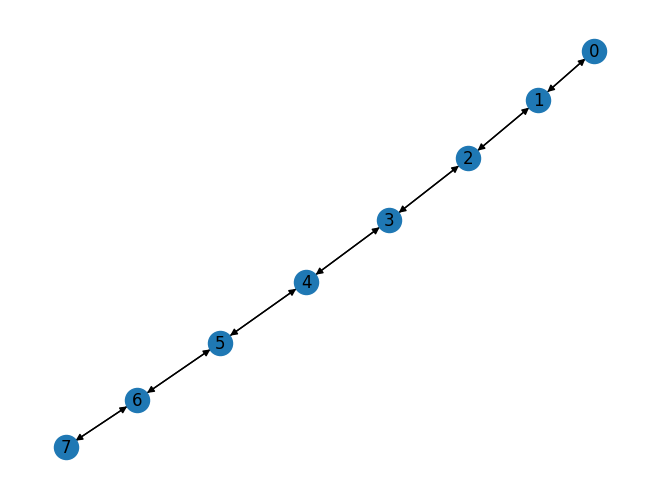

In [6]:
# Getting pagerank - pageranks are only applicable for directed graphs
num_nodes = 8
G = nx.DiGraph(nx.path_graph(num_nodes))
nx.draw(G, with_labels=True)

pr = nx.pagerank(G, alpha=0.8)
pr

Moving over to Pytorch-Geometric

In [7]:
# Helper function for visualization.
%matplotlib inline
import torch_geometric
import torch

import networkx as nx
import matplotlib.pyplot as plt

print(f"torch -> {torch.__version__}, torch_geometric -> {torch_geometric.__version__}")
print(f"networkx -> {nx.__version__}")
# Visualization function for NX graph or PyTorch tensor
def visualize(h, color, epoch=None, loss=None, accuracy=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
        if epoch is not None and loss is not None and accuracy['train'] is not None and accuracy['val'] is not None:
            plt.xlabel((f'Epoch: {epoch}, Loss: {loss.item():.4f} \n'
                       f'Training Accuracy: {accuracy["train"]*100:.2f}% \n'
                       f' Validation Accuracy: {accuracy["val"]*100:.2f}%'),
                       fontsize=16)
    else:
        nx.draw_networkx(h, pos=nx.spring_layout(h, seed=42), with_labels=False,
                         node_color=color, cmap="Set2")
    plt.show()

torch -> 2.2.0+cu118, torch_geometric -> 2.5.3
networkx -> 3.3


In [8]:
# import the Karateclub dataset - community detection - classify each node belonging to one communty/ class
from torch_geometric.datasets import KarateClub


dataset = KarateClub()  # create an object of the dataset
print(dataset)

print(f"number of graphs in dataset -> {len(dataset)}")
print(f"Nodes -> {dataset[0].num_nodes}")  # same as dataset.num_nodes in this case since there's only 1 graph
print(f"edges -> {dataset[0].num_edges}")
print(f"Features/ node -> {dataset.num_features}")
print(f"Number of classes (communities) -> {dataset.num_classes}")

KarateClub()
number of graphs in dataset -> 1
Nodes -> 34
edges -> 156
Features/ node -> 34
Number of classes (communities) -> 4


Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
num_nodes -> 34
num_edges -> 156
has_self_loop? -> False
has_isolated_nodes -> False
Number of training nodes -> 4
is_undirected -> True


tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

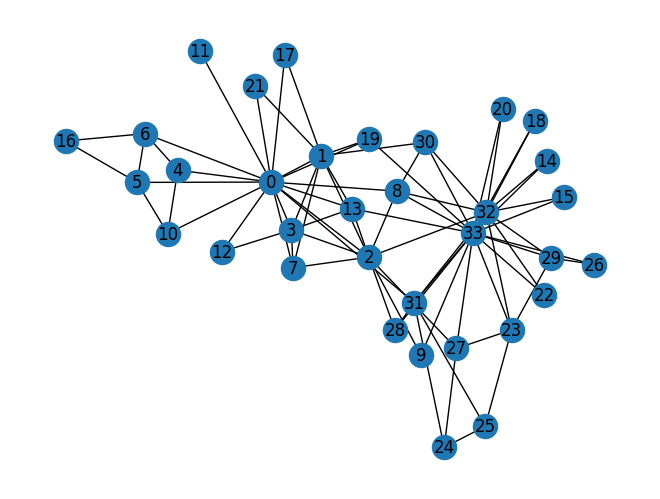

In [9]:
from torch_geometric.utils import to_networkx

# details for the graph
data = dataset[0]
print(data)

print(f"num_nodes -> {data.num_nodes}")
print(f"num_edges -> {data.num_edges}")
print(f"has_self_loop? -> {data.has_self_loops()}")
print(f"has_isolated_nodes -> {data.has_isolated_nodes()}")
print(f"Number of training nodes -> {data.train_mask.sum()}")
print(f"is_undirected -> {data.is_undirected()}")

# NOTE: convert to networkx graph for drawing
G = to_networkx(data, to_undirected=True)
nx.draw(G, with_labels=True)

data.edge_index.T  # prints nodes between which there are edges (u, v) format

Each graph in pytorch geometric is represented by a Data object


print(<data_obj>) prints a summary of key elements of the data object

We can see that this data object holds 4 attributes: (1) The edge_index property holds the information about the graph connectivity, i.e., a tuple of source and destination node indices for each edge. PyG further refers to (2) node features as x (each of the 34 nodes is assigned a 34-dim feature vector), and to (3) node labels as y (each node is assigned to exactly one class). (4) There also exists an additional attribute called train_mask, which describes for which nodes we already know their community assigments. In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

In [10]:
# x = nodes, features_per_node, y = labels, train_mask
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


By printing edge_index, we can further understand how PyG represents graph connectivity internally. We can see that for each edge, edge_index holds a tuple of two node indices, where the first value describes the node index of the source node and the second value describes the node index of the destination node of an edge.

This representation is known as the COO format (coordinate format) commonly used for representing sparse matrices. Instead of holding the adjacency information in a dense representation  A∈{0,1}|V|×|V| , PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in  A  are non-zero.

We can further visualize the graph by converting it to the networkx library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization:

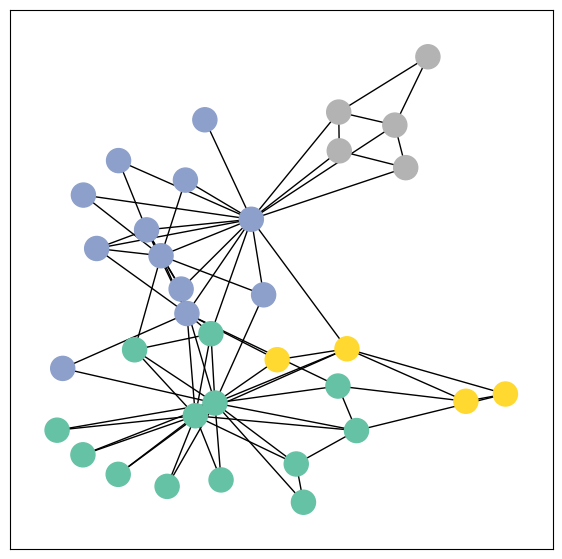

In [11]:
import matplotlib
matplotlib.__version__
G = to_networkx(data, to_undirected=True)
visualize(G, color=data.y)


The goal of a GNN is to take an input graph  G=(V,E)  where each node  vi∈V  has an input feature vector  X(0)i . 

What we want to learn is a function  f→V×Rd , a function that takes in a node and its feature vector, as well as the graph structure, and outputs an embedding, a vector that represents that node in a way that's useful to our downstream task. Once we've mapped nodes and their initial features to their learned embeddings, we can use those embeddings to do a variety of different tasks including node-level, edge-level, or graph-level regression/classification.

In this colab, we want to learn embeddings that will be useful to classify each node into its community.

PyG implements this layer via GCNConv, which can be executed by passing in the node feature representation x and the COO graph connectivity representation edge_index.

Here, we first initialize all of our building blocks in __init__ and define the computation flow of our network in forward. We first define and stack three graph convolution layers. Each layer corresponds to aggregating information from each node's 1-hop neighborhood (its direct neighbors), but when we compose the layers together, we are able to aggregate information from each node's 3-hop neighborhood (all nodes up to 3 "hops" away).

In addition, the GCNConv layers reduce the node feature dimensionality to  2 , i.e.,  34→4→4→2 . Each GCNConv layer is enhanced by a tanh non-linearity.

After that, we apply a single linear transformation (torch.nn.Linear) that acts as a classifier to map our nodes to 1 out of the 4 classes/communities.

We return both the output of the final classifier as well as the final node embeddings produced by our GNN. We proceed to initialize our final model via GCN(), and printing our model produces a summary of all its used sub-modules.

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)
Embedding shape: [34, 2]


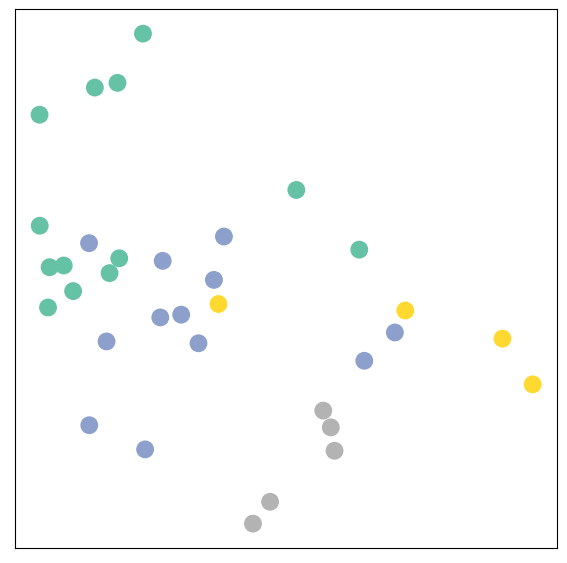

In [12]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)  # input: [N_nodes x N_feats], [2, N_edges], outputs: [N_nodes, n_feats_out]
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)  # final out: [N_nodes x N_classes]

        return out, h

model = GCN()
print(model)

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=data.y)

<IPython.core.display.Javascript object>

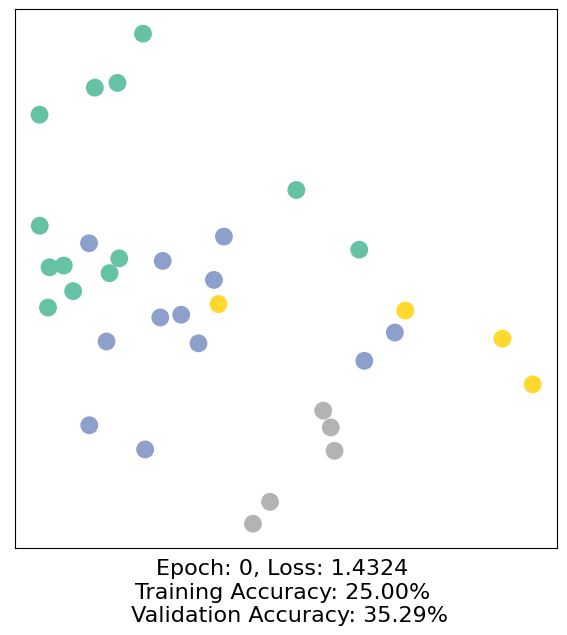

In [14]:
import time
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 430})'''))

model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.

    accuracy = {}
    # Calculate training accuracy on our four examples
    predicted_classes = torch.argmax(out[data.train_mask], axis=1) # [0.6, 0.2, 0.7, 0.1] -> 2
    target_classes = data.y[data.train_mask]
    accuracy['train'] = torch.mean(
        torch.where(predicted_classes == target_classes, 1, 0).float())

    # Calculate validation accuracy on the whole graph
    predicted_classes = torch.argmax(out, axis=1)
    target_classes = data.y
    accuracy['val'] = torch.mean(
        torch.where(predicted_classes == target_classes, 1, 0).float())

    return loss, h, accuracy

for epoch in range(10):
    loss, h, accuracy = train(data)
    # Visualize the node embeddings every 10 epochs
    if epoch % 10 == 0:
        visualize(h, color=data.y, epoch=epoch, loss=loss, accuracy=accuracy)
        time.sleep(0.3)